# Water isotopes

This is an isotope-enabled run, so the precipitation and sea-water isotopic
compositions are available. `d18Op` combines eight tagged precipitation fields; `dDp`
does the same for deuterium; `d18Osw` comes from `R18O`; and `d18Oc` converts
temperature and sea-water composition into the calcite value a proxy would record.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
from x4c import diags

case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)

>>> case.root_dir: /glade/u/home/fengzhu/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


In [3]:
ssh_path = os.path.join(case_dir, 'ocn', 'proc', 'tseries', 'month_1',
                        f'{casename}.pop.h.SSH.000101-000512.nc')
ssv = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH',
                       shift_time=True).x.regrid().x.da.mean('time')

In [4]:
iso = {}
for vn, span in [('d18Op', (1, 10)), ('dDp', (1, 10)),
                 ('d18Osw', (1, 1)), ('d18Oc', (1, 1))]:
    try:
        case.load(vn, timespan=span, verbose=False)
        iso[vn] = case.ds[vn]
        print(f'  {vn:7s} {str(dict(case.ds[vn].sizes)):48s} '
              f'{case.ds[vn].attrs.get("units")}')
    except Exception as e:
        print(f'  {vn:7s} unavailable: {type(e).__name__}: {str(e)[:60]}')

  d18Op   {'time': 120, 'ncol': 13826}                     permil


  dDp     {'time': 120, 'ncol': 13826}                     permil
  d18Osw  {'time': 12, 'z_t': 10, 'nlat': 384, 'nlon': 320} permil


  d18Oc   {'time': 12, 'z_t': 10, 'nlat': 384, 'nlon': 320} permil


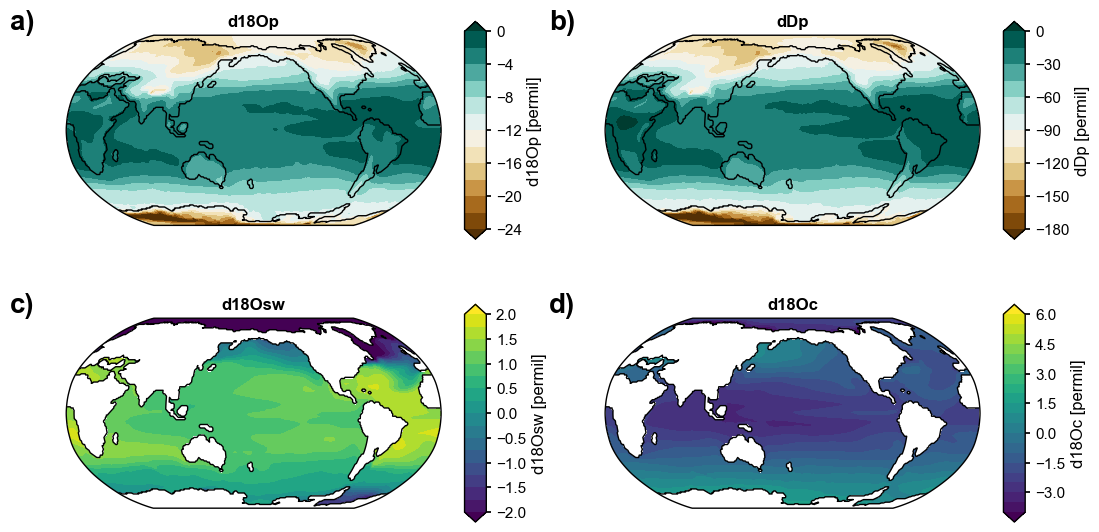

In [5]:
keys = [k for k in ['d18Op', 'dDp', 'd18Osw', 'd18Oc'] if k in iso]
ax_loc = {k: (i // 2, i % 2) for i, k in enumerate(keys)}
fig, axd = x4c.subplots(2, 2, ax_loc=ax_loc,
                        projs={k: 'Robinson' for k in ax_loc},
                        projs_kws={k: {'central_longitude': 180} for k in ax_loc},
                        figsize=(13, 6.5), wspace=0.15, hspace=0.3, annotation=True)

lv = {'d18Op': np.linspace(-24, 0, 13), 'dDp': np.linspace(-180, 0, 13),
      'd18Osw': np.linspace(-2, 2, 17), 'd18Oc': np.linspace(-4, 6, 21)}
for k in keys:
    da = iso[k]
    da = da.isel(z_t=0) if 'z_t' in da.dims else da
    da.x.regrid(2, 2).x.annualize().mean('time').x.plot(
        ax=axd[k], ssv=ssv, levels=lv[k], title=k)
x4c.showfig(fig)

## The d18O-temperature relationship

`d18Oc` is the quantity a carbonate proxy actually records, so plotting it against
temperature is the first check on a proxy-model comparison.

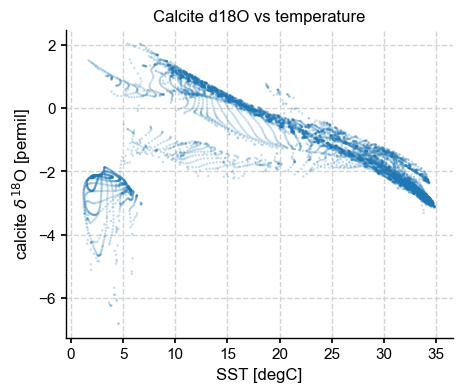

In [6]:
case.load('SST', timespan=(1, 1), verbose=False)
sst = case.ds['SST'].x.regrid(2, 2).mean('time')
d18oc = iso['d18Oc'].isel(z_t=0).x.regrid(2, 2).mean('time')

x = sst.values.ravel()
y = d18oc.values.ravel()
ok = np.isfinite(x) & np.isfinite(y)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x[ok], y[ok], s=3, alpha=0.25, edgecolors='none')
ax.set(xlabel='SST [degC]', ylabel=r'calcite $\delta^{18}$O [permil]',
       title='Calcite d18O vs temperature')
x4c.showfig(fig)